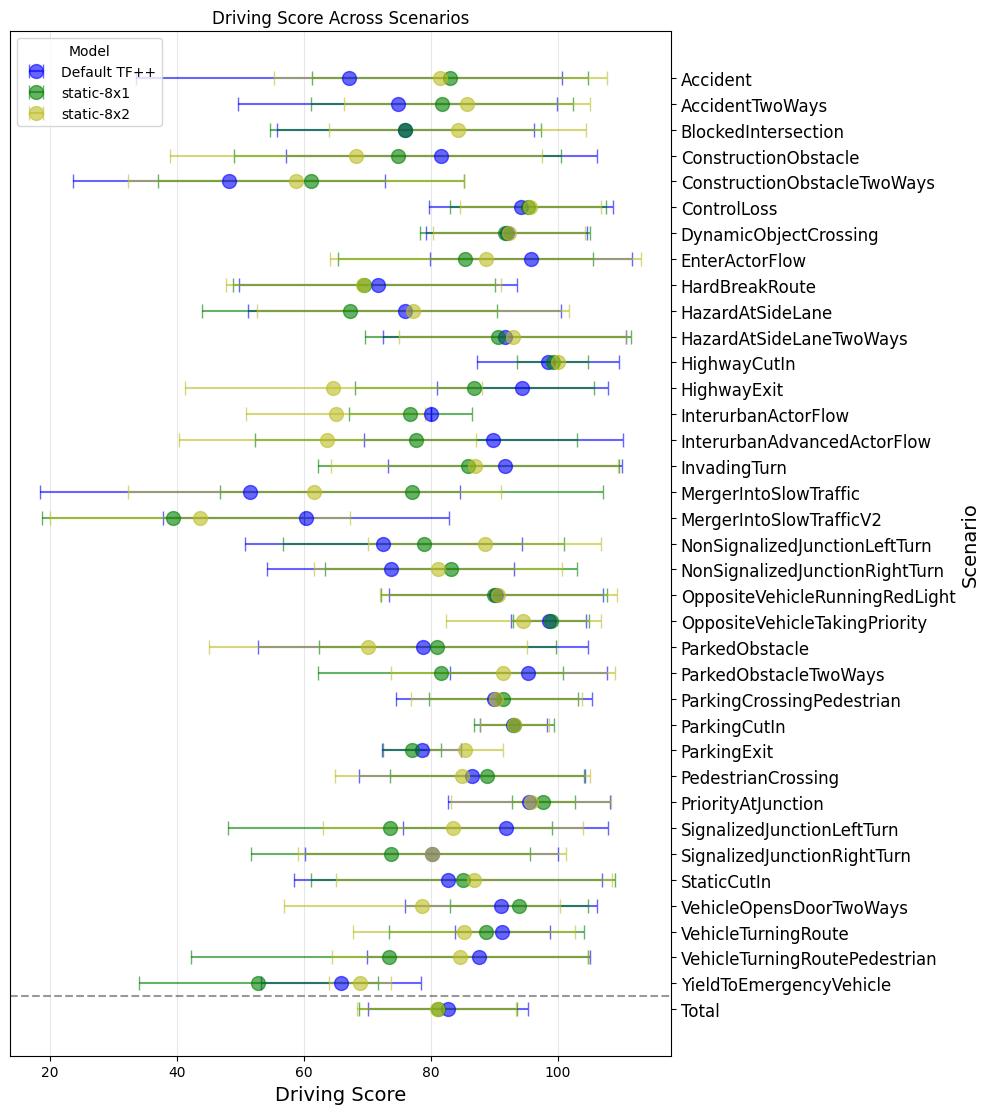

In [1]:
import ujson
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

path_template = "evaluation/routes_validation/{}_e30/{}_r0/results.json"

rename = {
    "tfpp_default": "Default TF++",
    "static-LB9s1": "static-8x1",
    "static-LB9s2": "static-8x2",
}

files = ["tfpp_default", "static-LB9s1", "static-LB9s2"]  # Replace with your files
score_type = "score_composed"  # Choose score_route, score_penalty, etc.
score_types = {
    "score_composed": "Driving Score",
    "score_route": "Route completion",
    "score_penalty": "Infraction score",
}

# Load data into a nested dictionary
scenario_data = defaultdict(list)
for file_name, file_ in [(f, path_template.format(f, f)) for f in files]:
    with open(file_, "r") as f:
        results = ujson.load(f)
        for scenario_name, scenario in results.items():
            scenario_data[scenario_name].append(
                {
                    "File": file_name,
                    "Mean": scenario["scores_mean"][score_type],
                    "Std": scenario["scores_std"][score_type],
                    "Min": scenario["scores_min"][score_type],
                    "Max": scenario["scores_max"][score_type],
                }
            )
scenario_data = dict(
    sorted(
        scenario_data.items(),
        key=lambda x: (chr(255) if x[0] == "Total" else x[0]),
        reverse=True,
    )
)

# Create horizontal dot plot with error bars
plt.figure(figsize=(10, len(scenario_data) * 0.25 + 2))  # Adjust height
# Create y-positions for scenarios
scenarios = scenario_data.keys()
y_pos = np.arange(len(scenarios))

colors = [
    "blue",
    "green",
    "tab:olive",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

# Plot each scenario
for scenario_idx, (scenario, values) in enumerate(scenario_data.items()):
    for file_idx, file_data in enumerate(values):
        plt.errorbar(
            x=file_data["Mean"],
            y=scenario_idx,
            xerr=file_data["Std"],
            fmt="o",
            capsize=5,
            label=rename[file_data["File"]] if scenario_idx == 0 else "",
            markersize=10,
            alpha=0.6,
            color=colors[file_idx],
        )

plt.axhline(
    0.5, color="black", linestyle="--", alpha=0.4
)  # Horizontal line, separate Total

# Customize plot
plt.yticks(y_pos, scenarios, fontsize=12)
plt.xlabel(score_types[score_type], fontsize=14)
plt.ylabel("Scenario", fontsize=14)
plt.title(f"{score_types[score_type]} Across Scenarios")
plt.grid(True, axis="x", alpha=0.3)

# Move scenario labels to right side
ax = plt.gca()
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()

# Adjust x-axis limits
all_means = [v["Mean"] for scenario in scenario_data.values() for v in scenario]
all_stds = [v["Std"] for scenario in scenario_data.values() for v in scenario]
buffer = max(all_stds) * 1.5 if all_stds else 5
# plt.xlim(left=max(0, min(all_means) - buffer),
#         right=min(115, max(all_means) + buffer))  # Assuming scores are 0-100

# Add legend
plt.legend(title="Model")

plt.tight_layout()
plt.show()

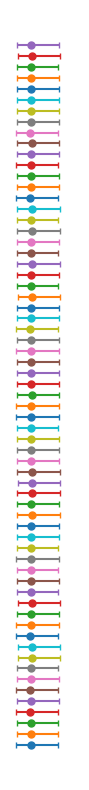

In [ ]:
import torch

cross_weight = ((torch.rand(65, 65) + 1) / 2) * 0.2
maxes, _ = cross_weight.max(dim=0)
mins, _ = cross_weight.min(dim=0)
means = cross_weight.mean(dim=0)

plt.figure(figsize=(1, 8))
plt.axis("off")
plt.xlim(0, 0.5)
for i, (min_, max_, mean) in enumerate(zip(mins, maxes, means)):
    err = np.array([min_.unsqueeze(-1), max_.unsqueeze(-1)])
    x = mean.unsqueeze(-1).numpy()
    plt.errorbar(
        x=x,
        y=i,
        xerr=err,
        fmt="o",
        capsize=2,
        label="Cross Weight",
        markersize=5,
        alpha=1.0,
    )
plt.tight_layout()

In [13]:
mins

torch.return_types.min(
values=tensor([0.0015, 0.0132, 0.0019, 0.0007, 0.0132, 0.0227, 0.0019, 0.0119, 0.0203,
        0.0108, 0.0131, 0.0184, 0.0130, 0.0026, 0.0035, 0.0078, 0.0244, 0.0296,
        0.0067, 0.0380, 0.0037, 0.0186, 0.0013, 0.0187, 0.0028, 0.0145, 0.0063,
        0.0038, 0.0117, 0.0092, 0.0107, 0.0107, 0.0338, 0.0115, 0.0111, 0.0138,
        0.0008, 0.0096, 0.0235, 0.0629, 0.0320, 0.0063, 0.0016, 0.0081, 0.0216,
        0.0101, 0.0023, 0.0131, 0.0346, 0.0509, 0.0187, 0.0140, 0.0090, 0.0257,
        0.0307, 0.0100, 0.0060, 0.0048, 0.0023, 0.0144, 0.1060, 0.0017, 0.0358,
        0.0093, 0.0061]),
indices=tensor([19, 38, 38, 58, 49, 56, 63, 52,  7, 21, 51, 42, 40, 48, 46, 41,  3,  9,
        64, 35,  4, 60,  8, 41, 55,  6, 61, 27, 19, 13, 38, 62, 13,  9, 54,  3,
        22, 28, 19,  7, 36,  7, 21, 40, 35, 16, 22, 45, 47, 16, 46, 57, 43, 18,
        47, 40,  5, 52, 36, 30, 45, 39, 34, 33, 28]))

In [26]:
template = "test_{}_2_{}"
template.format("model", "model")

'test_model_2_model'

In [35]:
import json
import os

path = "evaluation/merged_b2d"
data = {}

for f in os.listdir("evaluation/merged_b2d"):
    with open(os.path.join(path, f), "r") as file:
        data[f.split(".")[0]] = json.load(file)
data.keys()

dict_keys(['lidar-LB5s1', 'tfpp_default', 'static-LB5s1-large', 'static-LB5s1-notraj', 'static-LB9s1-notraj', 'LB5s1', 'static-LB9s2', 'static-LB9s1', 'static-LB5s1', 'static-LB5s1x'])

In [57]:
rename = {
    "static-LB9s1": "static-8x1",
    "static-LB9s2": "static-8x2",
    "static-LB9s1-notraj": "notraj-8x1*",
    "static-LB5s1-notraj": "notraj-5x1",
    "static-LB5s1": "static-5x1*",
    "LB5s1": "full-5x1",
    "static-LB5s1-large": "large-5x1",
    "lidar-LB5s1": "lidar-5x1",
    "tfpp_default": "TF++ Default",
    "static-LB5s1x": "static-5x1",
}
for k, v in data.items():
    name = rename.get(k.split('/')[-1].split('.')[0], None)
    v = {l: {n: m*100 if n not in ["driving score", "eval num"] else m for n, m in b.items()} for l, b in v.items()}
    v = v['std']
    print(
f"""\
{name:15} & \
{v['driving score']:.2f} & \
{v['success rate']:.2f} & \
{v['Merging']:.2f} & \
{v['Overtaking']:.2f} & \
{v['Emergency_Brake']:.2f} & \
{v['Give_Way']:.2f} & \
{v['Traffic_Signs']:.2f} & \
{v['mean']:.2f} \\\\
""", end="")

lidar-5x1       & 0.65 & 0.93 & 3.28 & 7.26 & 1.36 & 4.71 & 2.59 & 0.66 \\
TF++ Default    & 0.50 & 1.30 & 2.12 & 4.80 & 2.08 & 4.71 & 0.25 & 1.86 \\
large-5x1       & 0.81 & 1.13 & 0.59 & 1.05 & 2.72 & 0.00 & 1.51 & 1.13 \\
notraj-5x1      & 0.63 & 1.70 & 4.14 & 3.78 & 2.08 & 0.00 & 2.21 & 1.57 \\
notraj-8x1*     & 0.74 & 1.11 & 2.70 & 1.81 & 2.08 & 4.71 & 0.66 & 1.52 \\
full-5x1        & 0.30 & 0.21 & 1.18 & 2.77 & 1.36 & 0.00 & 0.43 & 0.54 \\
static-8x2      & 0.40 & 0.21 & 3.47 & 2.77 & 2.08 & 0.00 & 0.66 & 0.31 \\
static-8x1      & 0.63 & 1.62 & 4.25 & 1.81 & 1.36 & 4.71 & 1.49 & 0.42 \\
static-5x1*     & 0.30 & 0.43 & 2.04 & 0.00 & 1.57 & 0.00 & 0.74 & 0.14 \\
static-5x1      & 1.15 & 0.64 & 0.51 & 1.81 & 2.72 & 0.00 & 0.66 & 0.49 \\
